# Notebook 1: Geo-Spatial Data Preprocessing, PCA, and Classification
## Predicting Whether a Vienna Airbnb Listing Is Highly Rated

In this notebook, we move from raw geospatial Airbnb data to a fully evaluated classification workflow.

Our story is simple:

- every Airbnb listing is a **point in space**
- every neighborhood is a **polygon**
- machine learning needs **clean numerical representations**
- and a fair model must be tested on data it never saw during training

We will build two versions of the classifier:

1. a **raw baseline** with minimal preparation  
2. a **processed pipeline** with proper imputation, encoding, scaling, and richer features

That lets us directly compare model accuracy **with and without preprocessing**.

### Learning goals

By the end of this notebook, you should be able to:

- convert a plain CSV into a GeoDataFrame
- attach each listing to a Vienna neighborhood using a spatial join
- define a realistic classification target from raw Airbnb fields
- understand why preprocessing is often the most important part of machine learning
- apply PCA as a way to compress information
- train and compare several classification algorithms
- interpret accuracy, precision, recall, and a confusion matrix in plain language


In [1]:
# =========================
# 0. Imports and settings
# =========================
import ast
import re
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


## Semi-goal 1 — Load the data and make it spatial

A spreadsheet does not *know* that latitude and longitude are locations.  
We have to explicitly convert those columns into geometry.

Then we use a **spatial join** to answer a geographic question:

> Which Vienna neighborhood polygon contains each Airbnb point?

That is one of the most common GeoAI workflows: turning geometry into a feature source.


In [2]:
# ==========================================
# 1. Load the Airbnb CSV and neighborhood map
# ==========================================
LISTINGS_PATH = "listings_Vienna.csv"
NEIGHBOURHOODS_PATH = "neighbourhoods.geojson"

listings = pd.read_csv(LISTINGS_PATH)
neighbourhoods = gpd.read_file(NEIGHBOURHOODS_PATH)

print("Listings shape:", listings.shape)
print("Neighbourhood polygons shape:", neighbourhoods.shape)
print("\nFirst 20 columns:")
print(listings.columns[:20].tolist())

# Convert the plain table into a GeoDataFrame of listing points
listings_gdf = gpd.GeoDataFrame(
    listings.copy(),
    geometry=gpd.points_from_xy(listings["longitude"], listings["latitude"]),
    crs="EPSG:4326",
)

# Keep only the neighborhood label and geometry from the polygon file
poly_cols = [c for c in neighbourhoods.columns if c != "geometry"]
print("\nPolygon attributes:", poly_cols)

join_cols = []
if "neighbourhood" in neighbourhoods.columns:
    join_cols.append("neighbourhood")
elif "neighbourhoods" in neighbourhoods.columns:
    join_cols.append("neighbourhoods")
else:
    join_cols.append(poly_cols[0])

spatial = gpd.sjoin(
    listings_gdf,
    neighbourhoods[join_cols + ["geometry"]],
    how="left",
    predicate="within",
)

# Standardize the joined neighborhood column name
joined_candidates = [c for c in spatial.columns if c.startswith(join_cols[0])]
if f"{join_cols[0]}_right" in spatial.columns:
    spatial = spatial.rename(columns={f"{join_cols[0]}_right": "neighbourhood_joined"})
elif join_cols[0] in spatial.columns and "neighbourhood_joined" not in spatial.columns:
    spatial = spatial.rename(columns={join_cols[0]: "neighbourhood_joined"})

existing_neigh_col = "neighbourhood_cleansed" if "neighbourhood_cleansed" in spatial.columns else None

print("\nSpatial join complete.")
print("Joined shape:", spatial.shape)
if existing_neigh_col:
    match_rate = (
        spatial[existing_neigh_col].fillna("Missing")
        == spatial["neighbourhood_joined"].fillna("Missing")
    ).mean()
    print(f"Match rate between {existing_neigh_col} and polygon label: {match_rate:.3f}")


Listings shape: (14123, 79)
Neighbourhood polygons shape: (23, 3)

First 20 columns:
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url']

Polygon attributes: ['neighbourhood', 'neighbourhood_group']

Spatial join complete.
Joined shape: (14123, 82)
Match rate between neighbourhood_cleansed and polygon label: 1.000


## Quick map check

Before doing any machine learning, we should always ask:

- Do the points fall where we expect?
- Do the polygons look valid?
- Does the join seem sensible?

This is good GeoAI hygiene: first understand the spatial data, then model it.


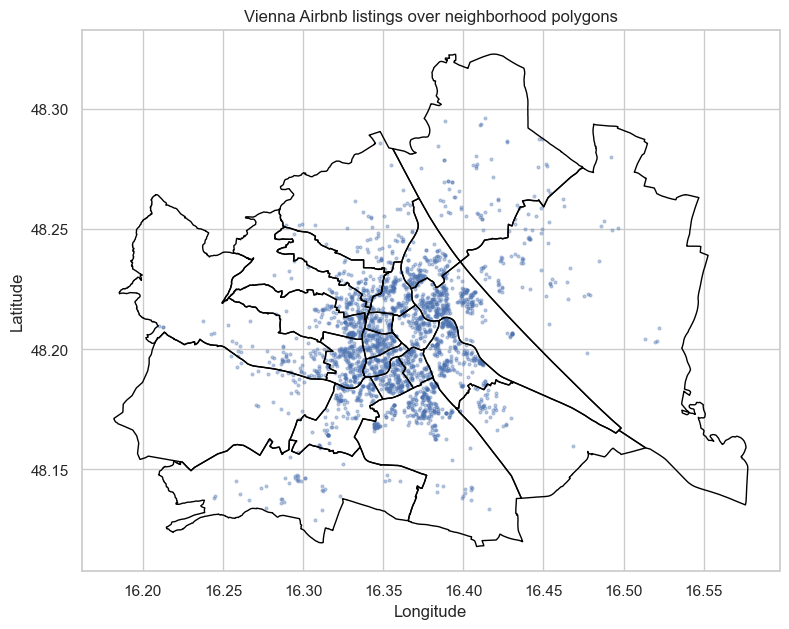

In [3]:
# ==========================
# 2. Basic visualization
# ==========================
fig, ax = plt.subplots(figsize=(9, 9))

neighbourhoods.boundary.plot(ax=ax, linewidth=1, color="black")
listings_gdf.sample(min(2500, len(listings_gdf)), random_state=RANDOM_STATE).plot(
    ax=ax,
    markersize=4,
    alpha=0.35,
)

ax.set_title("Vienna Airbnb listings over neighborhood polygons")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()


## Semi-goal 2 — Define the classification task

A good introductory target should be:

- meaningful in the Airbnb context
- not too imbalanced
- available in the actual file
- not contaminated by obvious leakage

We will predict whether a listing is **highly rated**:

- `highly_rated = 1` if `review_scores_rating >= 4.8`
- `highly_rated = 0` otherwise

To make this fair, we only keep listings with at least a small review history:

- `number_of_reviews >= 5`

We avoid using review sub-scores such as `review_scores_cleanliness` or `review_scores_communication` as predictors, because they are too close to the main rating and would make the task artificially easy.


In [6]:
# ==========================================
# 3. Define the target and filter the sample
# ==========================================
spatial["review_scores_rating"] = pd.to_numeric(
    spatial["review_scores_rating"], errors="coerce"
)

model_df = spatial.loc[
    (spatial["number_of_reviews"].fillna(0) >= 5)
    & (spatial["review_scores_rating"].notna())
].copy()

model_df["highly_rated"] = (model_df["review_scores_rating"] >= 4.8).astype(int)

print("Modeling sample shape:", model_df.shape)
print("\nClass balance:")
print(model_df["highly_rated"].value_counts())
print("\nClass proportions:")
print(model_df["highly_rated"].value_counts(normalize=True).round(3))


Modeling sample shape: (8886, 83)

Class balance:
highly_rated
1    4489
0    4397
Name: count, dtype: int64

Class proportions:
highly_rated
1    0.505
0    0.495
Name: proportion, dtype: float64


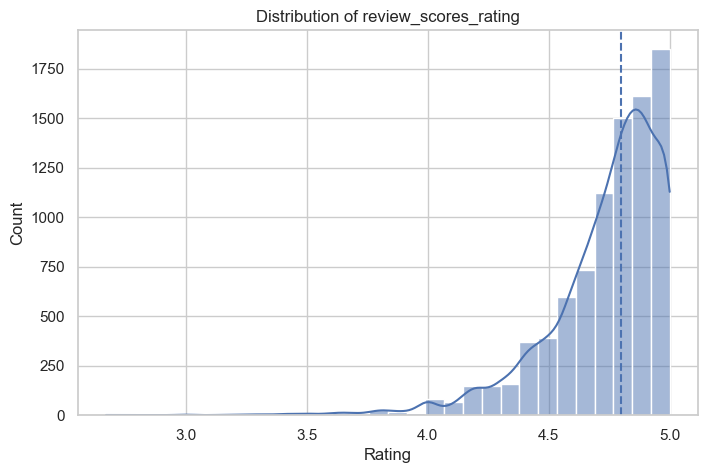

In [7]:
# Optional: inspect the target distribution
plt.figure(figsize=(8, 5))
sns.histplot(model_df["review_scores_rating"], bins=30, kde=True)
plt.axvline(4.8, linestyle="--")
plt.title("Distribution of review_scores_rating")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


## Semi-goal 2.5 — Choose features intentionally

Before training any model, we need to decide **what information the model is allowed to learn from**.

This is called **feature selection**. It is one of the most important design choices in machine learning.

A good feature should satisfy at least one of these:

- it captures something meaningful about the listing
- it helps distinguish patterns in guest experience
- it is available before the outcome is known
- it does not leak information too directly from the target

Our target is:

- `highly_rated = 1` if `review_scores_rating >= 4.8`
- `highly_rated = 0` otherwise

So our features should describe the listing, its host, and its spatial context — **not the rating itself in disguised form**.


## A quick reminder: feature selection is not the same as PCA

### Feature selection
Feature selection asks:

> Which original columns should we keep?

For example, we may decide to keep:

- `latitude`
- `room_type`
- `accommodates`
- `host_is_superhost`

because they are understandable and potentially useful.

### PCA
PCA asks:

> Can we combine several numeric columns into a smaller number of new directions that still preserve most of the information?

So PCA does **not** usually remove one original feature at a time.  
Instead, it creates new variables such as `PC1`, `PC2`, and `PC3`.

Each principal component is a weighted combination of several original numeric features.

### How we will use PCA here
In this notebook, PCA is used as an **extra learning experiment**, not as the main feature-selection strategy.

That means:

- the **main models** will use the original processed features
- PCA will be applied only to the **numeric subset**
- we will compare whether dimensionality reduction helps or hurts performance

This keeps the workflow interpretable while still teaching what PCA does.


## Selected features for the classification task

### 1. Spatial features

| Feature | Type | Why it may help |
|---|---|---|
| `latitude` | Numeric | Captures the north–south location of the listing. Different parts of Vienna may differ in accessibility, atmosphere, and guest appeal. |
| `longitude` | Numeric | Captures the east–west location of the listing. Together with latitude, it gives the model a basic sense of place. |
| `neighbourhood_joined` | Categorical | Encodes the local neighborhood context. Even listings with similar size may receive different guest experiences depending on where they are located. |

### 2. Property structure features

| Feature | Type | Why it may help |
|---|---|---|
| `room_type` | Categorical | Entire homes, private rooms, and shared rooms create very different guest experiences and expectations. |
| `property_type` | Categorical | Apartments, lofts, serviced units, and other property types may differ in comfort, style, and guest fit. |
| `accommodates` | Numeric | Indicates intended guest capacity. This helps describe the scale and use-case of the listing. |
| `bathrooms_num` | Numeric | Bathroom availability is a practical comfort factor that may affect satisfaction. |
| `bedrooms` | Numeric | Gives a simple measure of space and layout. More functional layouts may support better stays. |
| `beds` | Numeric | Affects sleeping arrangements and convenience, especially for groups. |
| `amenity_count` | Numeric | Acts as a rough proxy for how well-equipped or convenient the listing is. |

### 3. Booking policy and market behavior features

| Feature | Type | Why it may help |
|---|---|---|
| `minimum_nights` | Numeric | Reflects host policy and listing strategy. Very restrictive policies may attract a different guest segment. |
| `maximum_nights` | Numeric | Helps distinguish short-stay versus long-stay usage patterns. |
| `availability_365` | Numeric | Can reflect booking frequency, management style, or market position. |
| `instant_bookable_num` | Numeric | Easier booking can reduce guest friction and may be associated with smoother user experience. |

### 4. Review activity features

| Feature | Type | Why it may help |
|---|---|---|
| `number_of_reviews` | Numeric | Gives the listing a stronger experience history. More reviews often mean more observed guest interactions. |
| `reviews_per_month` | Numeric | Captures recent review activity and may reflect current popularity or demand. |
| `days_since_last_review` | Numeric | A recently reviewed listing may be more active and consistently maintained. |

### 5. Host behavior and trust features

| Feature | Type | Why it may help |
|---|---|---|
| `host_response_rate_num` | Numeric | Responsive hosts often provide better communication and smoother stays. |
| `host_acceptance_rate_num` | Numeric | May reflect how flexible or selective a host is with guests. |
| `host_response_time` | Categorical | Fast communication improves trust and reduces uncertainty before arrival. |
| `host_is_superhost_num` | Numeric | Superhost status is a strong platform-level signal of reliability and service quality. |
| `host_identity_verified_num` | Numeric | Verified identity can increase trust and perceived legitimacy. |
| `host_tenure_days` | Numeric | More experienced hosts may have learned how to manage the guest experience more effectively. |
| `calculated_host_listings_count` | Numeric | Helps distinguish small-scale hosts from more professional operators. |


## Features we intentionally exclude

### A. Direct identifiers

| Feature | Why exclude it |
|---|---|
| `id` | Pure identifier. It labels a row but contains no meaningful Airbnb quality information. |
| `host_id` | Another identifier. It may accidentally encode individual hosts, but it is not a principled predictive feature. |

### B. Text-heavy fields for a beginner notebook

| Feature | Why exclude it |
|---|---|
| `name` | Useful for advanced NLP work, but outside the scope of this introductory notebook. |
| `description` | Rich information, but requires text preprocessing that would distract from the core ML pipeline. |
| `host_about` | Same reason: potentially useful, but too advanced for this first notebook. |

### C. Leakage-prone review sub-scores

| Feature | Why exclude it |
|---|---|
| `review_scores_accuracy` | Too closely related to the overall rating target. |
| `review_scores_cleanliness` | Essentially a sibling outcome of the same guest evaluation process. |
| `review_scores_checkin` | Gives the model information too close to the target. |
| `review_scores_communication` | Strongly overlaps with the final rating signal. |
| `review_scores_location` | Also part of the rating family and would make the task too easy. |
| `review_scores_value` | Another near-target feature that weakens the teaching value of the exercise. |

### D. Downstream or business-style outcome variables

| Feature | Why exclude it |
|---|---|
| `estimated_occupancy_l365d` | More like a business result than a clean explanatory feature for this task. |
| `estimated_revenue_l365d` | A downstream performance indicator, not a simple input for guest satisfaction classification. |

### Important modeling idea: helpful does not mean causal

A feature can help prediction **without directly causing** the outcome.

For example, `number_of_reviews` may improve prediction, but that does **not** mean more reviews cause a higher rating.

It may simply be correlated with trust, listing maturity, visibility, or host experience.

In this notebook, we focus on **prediction**, not causal inference.


## First experiment: a raw baseline with almost no preprocessing

Before we build a careful pipeline, it is useful to ask:

> What happens if we are lazy?

So we start with a deliberately limited baseline:

- use only already-numeric columns
- do no categorical encoding
- do no scaling
- do no imputation beyond dropping incomplete rows

This is not best practice. It is a comparison point.


In [8]:
# ==========================================
# 4. Raw baseline features (minimal prep)
# ==========================================
raw_features = [
    "latitude",
    "longitude",
    "accommodates",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
]

baseline_df = model_df[raw_features + ["highly_rated"]].dropna().copy()

X_raw = baseline_df[raw_features]
y_raw = baseline_df["highly_rated"]

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_raw,
)

print("Raw baseline sample shape:", baseline_df.shape)
print("Train shape:", X_train_raw.shape)
print("Test shape:", X_test_raw.shape)


Raw baseline sample shape: (8886, 8)
Train shape: (6664, 7)
Test shape: (2222, 7)


## Why we split before doing serious preprocessing

The test set must stay hidden until the very end.

The same logic applies to transformations: if scaling, encoding, or imputation is learned from the full dataset, information can leak into the test side and make the model look better than it really is.

That is why we use the train/test split before the full preprocessing pipeline, and why later we place preprocessing inside a `Pipeline`.


In [9]:
# ==========================================
# 5. Helper function for classifier evaluation
# ==========================================
def evaluate_models(models, X_train, X_test, y_train, y_test):
    rows = []
    fitted_models = {}
    predictions = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        rows.append(
            {
                "Model": name,
                "Accuracy": accuracy_score(y_test, y_pred),
                "Precision": precision_score(y_test, y_pred),
                "Recall": recall_score(y_test, y_pred),
            }
        )

        fitted_models[name] = model
        predictions[name] = y_pred

    results = pd.DataFrame(rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)
    return results, fitted_models, predictions


In [10]:
# ==========================================
# 6. Train raw baseline models
# ==========================================
raw_models = {
    "Logistic Regression (raw)": LogisticRegression(max_iter=3000),
    "SVM (raw)": SVC(kernel="rbf"),
    "Decision Tree (raw)": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest (raw)": RandomForestClassifier(
        n_estimators=400,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
}

raw_results, raw_fitted, raw_preds = evaluate_models(
    raw_models,
    X_train_raw,
    X_test_raw,
    y_train_raw,
    y_test_raw,
)

raw_results


,Model,Accuracy,Precision,Recall
0,Random Forest (raw),0.642214,0.637353,0.677649
1,Decision Tree (raw),0.591359,0.597995,0.584150
2,Logistic Regression (raw),0.567057,0.566584,0.609973
3,SVM (raw),0.560756,0.550936,0.707925


## Interpreting the metrics

- **Accuracy**: overall fraction of correct predictions  
- **Precision**: among listings predicted as highly rated, how many truly were highly rated?  
- **Recall**: among the truly highly rated listings, how many did we successfully find?  

In Airbnb language:

- high **precision** means we do not over-promise too many ordinary listings as excellent
- high **recall** means we do not miss too many genuinely excellent listings

A confusion matrix summarizes all of this using true positives, true negatives, false positives, and false negatives.


## Semi-goal 3 — Proper data preparation

Now we move from the lazy baseline to the real machine-learning workflow.

Some columns are not ready to learn from yet:

- `host_response_rate` looks like `"93%"`
- `bathrooms_text` looks like `"1 bath"` or `"1.5 baths"`
- `amenities` is stored as a text representation of a list
- `host_is_superhost` and `instant_bookable` are stored as `"t"` / `"f"`

These are not hard problems, but they are exactly the kind of practical data preparation work a real project requires.

We distinguish two kinds of preparation:

1. **deterministic parsing** — converting strings like `"93%"` into numbers like `0.93`  
2. **learned transformations** — imputation, scaling, and encoding, which must be fit on the training data only


In [11]:
# ==========================================
# 7. Deterministic parsing / light feature engineering
# ==========================================
def parse_percent(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().replace("%", "")
    if text == "":
        return np.nan
    return float(text) / 100.0

def parse_tf(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    if text in {"t", "true", "yes", "1"}:
        return 1
    if text in {"f", "false", "no", "0"}:
        return 0
    return np.nan

def parse_bathrooms(text):
    if pd.isna(text):
        return np.nan
    s = str(text).lower()

    if "half-bath" in s:
        return 0.5

    match = re.search(r"(\d+(?:\.\d+)?)", s)
    if match:
        return float(match.group(1))

    if "bath" in s:
        return 1.0

    return np.nan

def count_amenities(text):
    if pd.isna(text):
        return np.nan

    s = str(text).strip()

    if s in {"", "[]"}:
        return 0

    try:
        items = ast.literal_eval(s)
        if isinstance(items, (list, tuple, set)):
            return len(items)
    except Exception:
        pass

    # Fallback parser if literal_eval fails
    s = s.strip("[]")
    if not s:
        return 0

    pieces = [piece for piece in s.split('","') if piece.strip()]
    return len(pieces)

prep_df = model_df.copy()

prep_df["host_response_rate_num"] = prep_df["host_response_rate"].map(parse_percent)
prep_df["host_acceptance_rate_num"] = prep_df["host_acceptance_rate"].map(parse_percent)

prep_df["host_is_superhost_num"] = prep_df["host_is_superhost"].map(parse_tf)
prep_df["host_identity_verified_num"] = prep_df["host_identity_verified"].map(parse_tf)
prep_df["instant_bookable_num"] = prep_df["instant_bookable"].map(parse_tf)

prep_df["bathrooms_num"] = prep_df["bathrooms_text"].map(parse_bathrooms)
prep_df["amenity_count"] = prep_df["amenities"].map(count_amenities)

prep_df["host_since"] = pd.to_datetime(prep_df["host_since"], errors="coerce")
prep_df["last_review"] = pd.to_datetime(prep_df["last_review"], errors="coerce")
prep_df["last_scraped"] = pd.to_datetime(prep_df["last_scraped"], errors="coerce")

reference_date = prep_df["last_scraped"].max()

prep_df["host_tenure_days"] = (reference_date - prep_df["host_since"]).dt.days
prep_df["days_since_last_review"] = (reference_date - prep_df["last_review"]).dt.days


In [12]:
# Quick sanity check of engineered features
check_cols = [
    "host_response_rate_num",
    "host_acceptance_rate_num",
    "bathrooms_num",
    "amenity_count",
    "host_is_superhost_num",
    "instant_bookable_num",
    "host_tenure_days",
    "days_since_last_review"
]
prep_df[check_cols].describe(include="all").T


,count,mean,std,min,25%,50%,75%,max
host_response_rate_num,7026.0,0.959866,0.133382,0.0,0.99,1.00,1.0,1.0
host_acceptance_rate_num,7374.0,0.914169,0.192321,0.0,0.94,0.99,1.0,1.0
bathrooms_num,8885.0,1.178109,0.432186,0.0,1.00,1.00,1.5,10.0
amenity_count,8886.0,32.485483,13.408183,2.0,23.00,33.00,42.0,83.0
host_is_superhost_num,8610.0,0.340650,0.473955,0.0,0.00,0.00,1.0,1.0
instant_bookable_num,8886.0,0.528809,0.499197,0.0,0.00,1.00,1.0,1.0
host_tenure_days,8884.0,2713.333746,1420.517673,32.0,1341.75,2937.00,3830.0,6103.0
days_since_last_review,8886.0,376.181859,766.394259,1.0,15.00,37.00,255.0,4016.0


## Feature set for the processed workflow

We now use a richer feature set.

- **Numeric features** can be scaled and used directly by PCA or classifiers.
- **Categorical features** need one-hot encoding so the model can treat categories as machine-readable indicators.

This is exactly why `ColumnTransformer` exists: it lets us apply different preprocessing steps to different feature groups and combine the results into one design matrix.


In [13]:
# ==========================================
# 8. Final feature lists
# ==========================================
numeric_features = [
    "latitude",
    "longitude",
    "accommodates",
    "bathrooms_num",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "host_response_rate_num",
    "host_acceptance_rate_num",
    "host_is_superhost_num",
    "host_identity_verified_num",
    "instant_bookable_num",
    "host_tenure_days",
    "days_since_last_review",
    "amenity_count",
    "calculated_host_listings_count",
]

categorical_features = [
    "room_type",
    "property_type",
    "neighbourhood_joined",
    "host_response_time",
]

excluded_features = [
    "id",
    "host_id",
    "name",
    "description",
    "host_about",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d",
]

print("Numeric features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

print("\nExcluded features:", len(excluded_features))
print(excluded_features)

X = prep_df[numeric_features + categorical_features].copy()
y = prep_df["highly_rated"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("\nProcessed workflow train shape:", X_train.shape)
print("Processed workflow test shape:", X_test.shape)


Numeric features: 20
['latitude', 'longitude', 'accommodates', 'bathrooms_num', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'availability_365', 'number_of_reviews', 'reviews_per_month', 'host_response_rate_num', 'host_acceptance_rate_num', 'host_is_superhost_num', 'host_identity_verified_num', 'instant_bookable_num', 'host_tenure_days', 'days_since_last_review', 'amenity_count', 'calculated_host_listings_count']

Categorical features: 4
['room_type', 'property_type', 'neighbourhood_joined', 'host_response_time']

Excluded features: 13
['id', 'host_id', 'name', 'description', 'host_about', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'estimated_occupancy_l365d', 'estimated_revenue_l365d']

Processed workflow train shape: (6664, 24)
Processed workflow test shape: (2222, 24)


## PCA intuition: the “best camera angle” idea

PCA does not care about labels at first. It looks only at the feature cloud and asks:

> Can I rotate this cloud of points so that the first new axis captures as much variation as possible?

A simple way to picture this is to imagine taking a photo of a 3D object. Some camera angles preserve the object’s shape better than others. PCA tries to find the best viewing directions in a higher-dimensional feature space.

In this notebook, PCA is used as a **teaching experiment**. It helps students see how numeric information can be compressed, but the main classifier comparison still uses the original processed features because those remain easier to interpret.


Components needed for 90% cumulative variance: 15
Components needed for 95% cumulative variance: 17


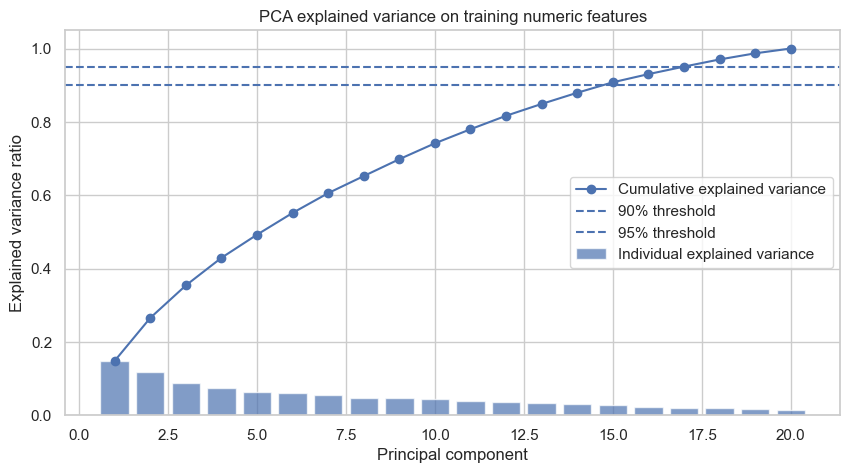

In [14]:
# ==========================================
# 9. PCA on the numeric branch only
#    IMPORTANT: fit only on training data
# ==========================================
numeric_imputer = SimpleImputer(strategy="median")
numeric_scaler = StandardScaler()

X_train_num = numeric_imputer.fit_transform(X_train[numeric_features])
X_train_num_scaled = numeric_scaler.fit_transform(X_train_num)

pca = PCA()
pca.fit(X_train_num_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

n90 = np.argmax(cumulative >= 0.90) + 1
n95 = np.argmax(cumulative >= 0.95) + 1

print(f"Components needed for 90% cumulative variance: {n90}")
print(f"Components needed for 95% cumulative variance: {n95}")

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(explained) + 1), explained, alpha=0.7, label="Individual explained variance")
plt.plot(range(1, len(cumulative) + 1), cumulative, marker="o", label="Cumulative explained variance")
plt.axhline(0.90, linestyle="--", label="90% threshold")
plt.axhline(0.95, linestyle="--", label="95% threshold")
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("PCA explained variance on training numeric features")
plt.legend()
plt.show()


## Why scaling matters before PCA and before some classifiers

PCA and models like Logistic Regression and SVM are sensitive to feature scale.

For example:

- `availability_365` ranges into the hundreds
- `host_response_rate_num` is between 0 and 1
- latitude and longitude have their own scale
- review counts can be very large

If we skip scaling, large-number features can dominate just because of units, not because they are truly more informative.

That is why we place `StandardScaler()` inside the numeric preprocessing branch.


In [15]:
# ==========================================
# 10. Preprocessing pipelines
# ==========================================
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


## Semi-goal 4 — Train the processed classifiers

We now train four supervised classifiers:

- Logistic Regression
- Support Vector Machine
- Decision Tree
- Random Forest

This gives us a nice spectrum:

- linear boundary
- flexible margin-based boundary
- single tree rules
- ensemble of many trees


In [16]:
# ==========================================
# 11. Helper for processed models
# ==========================================
def evaluate_pipeline_models(models, preprocessor, X_train, X_test, y_train, y_test):
    rows = []
    fitted_pipelines = {}
    predictions = {}

    for name, model in models.items():
        pipe = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("classifier", model),
            ]
        )

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        rows.append(
            {
                "Model": name,
                "Accuracy": accuracy_score(y_test, y_pred),
                "Precision": precision_score(y_test, y_pred),
                "Recall": recall_score(y_test, y_pred),
            }
        )

        fitted_pipelines[name] = pipe
        predictions[name] = y_pred

    results = pd.DataFrame(rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)
    return results, fitted_pipelines, predictions


In [17]:
# ==========================================
# 12. Train processed models
# ==========================================
processed_models = {
    "Logistic Regression (processed)": LogisticRegression(max_iter=3000),
    "SVM (processed)": SVC(kernel="rbf"),
    "Decision Tree (processed)": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        max_depth=8,
        min_samples_leaf=10,
    ),
    "Random Forest (processed)": RandomForestClassifier(
        n_estimators=400,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        min_samples_leaf=3,
    ),
}

processed_results, processed_fitted, processed_preds = evaluate_pipeline_models(
    processed_models,
    preprocessor,
    X_train,
    X_test,
    y_train,
    y_test,
)

processed_results


,Model,Accuracy,Precision,Recall
0,Random Forest (processed),0.743474,0.741485,0.756011
1,SVM (processed),0.727273,0.731839,0.726625
2,Logistic Regression (processed),0.718272,0.726941,0.708816
3,Decision Tree (processed),0.716022,0.721223,0.714159


## Compare accuracy with and without preprocessing

This is one of the main teaching goals of the notebook.

The raw baseline answers:

> How far can we get with minimal preparation?

The processed workflow answers:

> What changes when we respect the data?

In most real-world projects, the second jump is often larger than the jump from one fancy model to another.


In [18]:
# ==========================================
# 13. Side-by-side comparison table
# ==========================================
raw_results_for_compare = raw_results.copy()
raw_results_for_compare["Stage"] = "Without preprocessing"

processed_results_for_compare = processed_results.copy()
processed_results_for_compare["Stage"] = "With preprocessing"

comparison = pd.concat(
    [raw_results_for_compare, processed_results_for_compare],
    ignore_index=True,
)

comparison = comparison[["Stage", "Model", "Accuracy", "Precision", "Recall"]]
comparison.sort_values(["Stage", "Accuracy"], ascending=[True, False]).reset_index(drop=True)


,Stage,Model,Accuracy,Precision,Recall
0,With preprocessing,Random Forest (processed),0.743474,0.741485,0.756011
1,With preprocessing,SVM (processed),0.727273,0.731839,0.726625
2,With preprocessing,Logistic Regression (processed),0.718272,0.726941,0.708816
3,With preprocessing,Decision Tree (processed),0.716022,0.721223,0.714159
4,Without preprocessing,Random Forest (raw),0.642214,0.637353,0.677649
5,Without preprocessing,Decision Tree (raw),0.591359,0.597995,0.584150
6,Without preprocessing,Logistic Regression (raw),0.567057,0.566584,0.609973
7,Without preprocessing,SVM (raw),0.560756,0.550936,0.707925


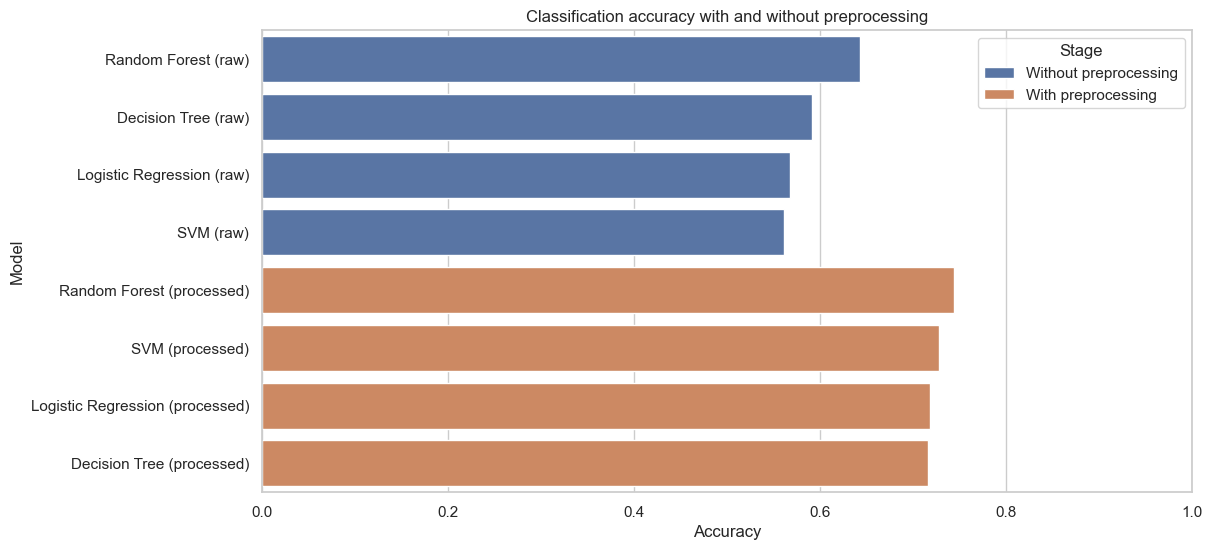

In [19]:
# ==========================================
# 14. Visual comparison of accuracy
# ==========================================
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison, x="Accuracy", y="Model", hue="Stage")
plt.title("Classification accuracy with and without preprocessing")
plt.xlim(0, 1)
plt.show()


## Confusion matrix: what kinds of mistakes are we making?

A confusion matrix tells us not only **how much** we are wrong, but also **how** we are wrong.

For this Airbnb task:

- **True Positive**: the model says “highly rated,” and the listing truly is highly rated
- **False Positive**: the model over-promises quality
- **False Negative**: the model misses a genuinely highly rated listing
- **True Negative**: the model correctly identifies a listing below the threshold


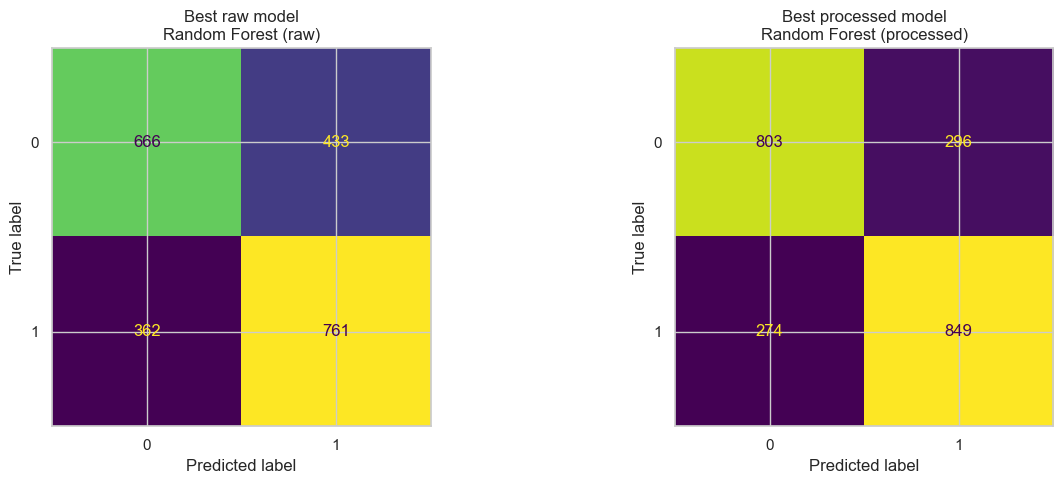

In [20]:
# ==========================================
# 15. Compare the best raw model vs. best processed model
# ==========================================
best_raw_name = raw_results.iloc[0]["Model"]
best_processed_name = processed_results.iloc[0]["Model"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test_raw,
    raw_preds[best_raw_name],
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title(f"Best raw model\n{best_raw_name}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    processed_preds[best_processed_name],
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title(f"Best processed model\n{best_processed_name}")

plt.tight_layout()
plt.show()


## What did preprocessing buy us?

Reflect on the jump from the raw baseline to the processed workflow.

Usually, the gain comes from several things at once:

- richer and more meaningful features
- cleaner numeric values from messy text columns
- access to categorical information through one-hot encoding
- proper scaling for distance-sensitive models
- fairer handling of missing values
- leak-safe transformation through pipelines

This is a major machine learning lesson:

> **Better data representation often matters as much as, or more than, the choice of model.**


In [21]:
# ==========================================
# 16. Optional: export a cleaned table for Notebook 2
# ==========================================
export_columns = numeric_features + categorical_features + ["price", "review_scores_rating", "highly_rated"]
notebook2_ready = prep_df[export_columns].copy()
notebook2_ready.to_csv("vienna_airbnb_notebook2_ready.csv", index=False)

print("Saved: vienna_airbnb_notebook2_ready.csv")


Saved: vienna_airbnb_notebook2_ready.csv


## Final interpretation

By the end of this notebook, we have learned three big ideas:

1. **Geography matters**  
   Listings are not just rows. They live in neighborhoods, and space can become a predictive feature.

2. **Preprocessing matters**  
   Raw real-world data is rarely ready for machine learning.

3. **Evaluation matters**  
   Accuracy, precision, recall, and the confusion matrix tell different parts of the story.

In the next notebook, we will reuse this cleaned, spatially enriched data and switch from classification to **regression**, where the goal will be to predict nightly Airbnb price.
